In [1]:
from gym import envs
import gym

In [2]:
env = gym.make('MountainCar-v0')

In [3]:
observation = env.reset()
print(observation)

[-0.59905027  0.        ]


In [4]:
print(env.observation_space)

Box(-1.2000000476837158, 0.6000000238418579, (2,), float32)


In [5]:
# 何もしない
action = 1
observation, reward, done, info = env.step(action)
print(observation)

[-5.98489201e-01  5.61066225e-04]


In [6]:
print(observation)

[-5.98489201e-01  5.61066225e-04]


In [7]:
# 左
action = 0
observation, reward, done, info = env.step(action)
print(observation)

[-5.98371170e-01  1.18031002e-04]


In [8]:
# display関連
!apt-get install -y xvfb python-opengl > /dev/null 2>&1
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!pip install JSAnimation

In [9]:
# display関連
from pyvirtualdisplay import Display
pydisplay = Display(visible=0, size=(400, 300))
pydisplay.start()

In [10]:
import numpy as np
import copy
from collections import deque
import gym
from gym import wrappers
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical, Normal
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt

from IPython import display
from JSAnimation.IPython_display import display_animation
from IPython.display import HTML

In [11]:
# install required system dependencies
!apt-get install -y xvfb x11-utils

# install required python dependencies (might need to install additional gym extras depending)
!pip install gym[box2d]==0.17.* pyvirtualdisplay==0.2.* PyOpenGL==3.1.* PyOpenGL-accelerate==3.1.*!

Reading package lists... Done
Building dependency tree       
Reading state information... Done
x11-utils is already the newest version (7.7+3build1).
xvfb is already the newest version (2:1.19.6-1ubuntu4.8).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
  Using cached https://files.pythonhosted.org/packages/69/ec/8221a07850d69fa3c57c02e526edd23d18c7c05d58ed103e3b19172757c1/PyVirtualDisplay-0.2.5-py2.py3-none-any.whl
ERROR: Could not find a version that satisfies the requirement PyOpenGL-accelerate==3.1.*! (from versions: 3.0.1b1, 3.0.1b2, 3.0.1, 3.0.2a1, 3.0.2b2, 3.0.2, 3.1.0a1, 3.1.0a3, 3.1.0b1, 3.1.0b2, 3.1.0b3, 3.1.0, 3.1.1a1, 3.1.3b1, 3.1.3rc1, 3.1.4, 3.1.5)
ERROR: No matching distribution found for PyOpenGL-accelerate==3.1.*!


In [12]:
frames = []
for episode in range(5):
    state = env.reset()  # エピソードを開始（環境の初期化）
    env.render()  # シミュレータ画面の出力
    screen = env.render(mode='rgb_array')  # notebook上での結果の可視化用
    frames.append(screen)
    done = False
    while not done:
        action = env.action_space.sample()  # 行動をランダムに選択
        next_state, reward, done, _ = env.step(action)  # 行動を実行し、次の状態、 報酬、 終端か否かの情報を取得
        env.render()
        screen = env.render(mode='rgb_array')
        frames.append(screen)
env.close()  # 画面出力の終了

In [13]:
# 結果の確認
plt.figure(figsize=(frames[0].shape[1]/72.0, frames[0].shape[0]/72.0), dpi=72)
# dpi は 1 インチあたりのドット数を表します。 これは、図の 1 インチあたりのピクセル数を表します。線の太さとか。 matplotlib.pyplot.figure() 関数の dpi のデフォルト値は 100 です。 より高い値の dpi を設定して、高解像度のプロットを生成できます。
patch = plt.imshow(frames[0])
plt.axis('off') # 枠と目盛りを消去
  
def animate(i):
    patch.set_data(frames[i])
    
anim = animation.FuncAnimation(plt.gcf(), animate, frames=len(frames), interval=50)
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [14]:
a = [1,2,3,4,5]
a[1:-1]

[2, 3, 4]

In [15]:
# 状態を離散化する便利関数
# 状態が位置、速度の2次元 → 「num_discretize」等分する　行動が left, no push, right の3つ
def bins(clip_min, clip_max, num):
    return np.linspace(clip_min, clip_max, num=num+1)[1:-1] # numは分ける個数 clip_minからclip_maxの値をnum個で等分する

# 状態を離散化して対応するインデックスを返す関数（binの上限・下限はcartpole環境固有のものを用いています）
def discretize_state(observation, num_discretize):
    pos, vel = observation # cartの座標、速度 poleの座標、速度
    discretized = [
        np.digitize(pos, bins=bins(-1.2, 0.6, num_discretize)),  # 上のbins関数を使ってbinを作っている それぞれの値がbinのどこにあるかをindexで返す
        np.digitize(vel, bins=bins(-0.07, 0.07, num_discretize)),
    ]
    # discretized is like [2,3,1,3]
    return sum([x*(num_discretize**i) for i, x in enumerate(discretized)])

In [16]:
# SARSAのAgentを作成する
class SarsaAgent:
    # selfはインスタンスを表す
    # コンストラクタ インスタンス作成時に呼び出される
    def __init__(self, num_state, num_action, num_discretize, gamma=0.99, alpha=0.5, max_initial_q=0.1):
        self.num_action = num_action
        self.gamma = gamma # 割引率
        self.alpha = alpha # 学習率
        # Qテーブルを作成し乱数で初期化 lowからhighの値で初期化 sizeの配列で出力 適当に初期化して収束するまで更新し続ける
        # size ⇒ 30^2×3 = 108 個
        # tableみたいに2次元配列にしたいときはsizeはタプルで渡す。返り値はnumpyの2次元配列（行列）
        self.qtable = np.random.uniform(low=-max_initial_q, high=max_initial_q, size=(num_discretize**num_state, num_action))

    # Q tableを更新する    
    def update_qtable(self, state, action, reward, next_state, next_action):
        self.qtable[state][action] += self.alpha*(reward + self.gamma*self.qtable[next_state][next_action] - self.qtable[state][action])

    # greedyな方策（Qが最大となる方向へのactionをとる方策）
    def get_greedy_action(self, state):
        action = np.argmax(self.qtable[state])
        return action

    # ε- greedyの方策
    def get_action(self, state, episode):
        epsilon = 0.7 * (1/(episode+1)) #どんどん探索（ランダム行動）の割合が小さくなるように 0.7から減衰
        if epsilon <= np.random.uniform(0,1):
            action = self.get_greedy_action(state)
        else:
            action = np.random.choice(self.num_action)
        return action

Hi I'm constructor
Episode 0 finished | Episode reward -200.000000
Episode 50 finished | Episode reward -200.000000
Episode 100 finished | Episode reward -200.000000
Episode 150 finished | Episode reward -200.000000
Episode 200 finished | Episode reward -200.000000
Episode 250 finished | Episode reward -200.000000
Episode 300 finished | Episode reward -200.000000
Episode 350 finished | Episode reward -200.000000
Episode 400 finished | Episode reward -165.000000
Episode 450 finished | Episode reward -200.000000
Episode 500 finished | Episode reward -200.000000
Episode 550 finished | Episode reward -200.000000
Episode 600 finished | Episode reward -200.000000
Episode 650 finished | Episode reward -200.000000
Episode 700 finished | Episode reward -200.000000
Episode 750 finished | Episode reward -200.000000
Episode 800 finished | Episode reward -200.000000
Episode 850 finished | Episode reward -200.000000
Episode 900 finished | Episode reward -152.000000
Episode 950 finished | Episode rew

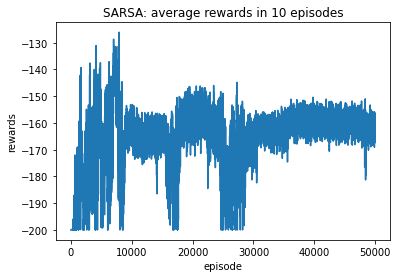

In [17]:
# 学習start!

# settings
num_episodes = 50000
num_discretize = 30

# log 
episode_rewards = []
num_average_episodes = 10

# Agentの学習
env = gym.make('MountainCar-v0')
max_steps = env.spec.max_episode_steps
agent = SarsaAgent(env.observation_space.shape[0], env.action_space.n, num_discretize)
for episode in range(num_episodes):
    observation = env.reset() # 初期化 初期値を得る
    state = discretize_state(observation, num_discretize)
    action = agent.get_action(state, episode)
    episode_reward = 0
    for step in range(max_steps):
        observation, reward, done, _ = env.step(action)
        episode_reward += reward
        next_state = discretize_state(observation, num_discretize)
        next_action = agent.get_action(next_state, episode)
        agent.update_qtable(state, action, reward, next_state, next_action)
        state, action = next_state, next_action
        if done:
            break
    episode_rewards.append(episode_reward)
    if episode % 1000 == 0:
        print("Episode %d finished | Episode reward %f" % (episode, episode_reward))

# 学習の経過（累積報酬の移動平均）を表示
moving_average = np.convolve(episode_rewards, np.ones(num_average_episodes)/num_average_episodes, mode='valid')
plt.plot(np.arange(len(moving_average)),moving_average)
plt.title('SARSA: average rewards in %d episodes' % num_average_episodes)
plt.xlabel('episode')
plt.ylabel('rewards')
plt.show()

env.close()

In [19]:
# 最終的に得られた方策のテスト（可視化）
env = gym.make('MountainCar-v0')
frames = []
for episode in range(5):
    observation = env.reset()
    state = discretize_state(observation, num_discretize)
    frames.append(env.render(mode='rgb_array'))
    done = False
    while not done:
        action = agent.get_greedy_action(state)
        next_observation, reward, done, _ = env.step(action)
        frames.append(env.render(mode='rgb_array'))
        state = discretize_state(next_observation, num_discretize)
env.close()

plt.figure(figsize=(frames[0].shape[1]/72.0, frames[0].shape[0]/72.0), dpi=72)
patch = plt.imshow(frames[0])
plt.axis('off')
  
def animate(i):
    patch.set_data(frames[i])
    
anim = animation.FuncAnimation(plt.gcf(), animate, frames=len(frames), interval=50)
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.